<a href="https://colab.research.google.com/github/sudulran/IT3051-Group27-Hotel-Cancellation-Prediction/blob/main/notebooks/01_Data_Understanding_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hotel Booking Cancellation Prediction

## Notebook 01 — Data Understanding and Exploratory Data Analysis

**Module:** IT3051 – Fundamentals of Data Mining  
**Group:** Group 27 – Entropy Zero

### Machine Learning Task

Binary Classification

### Target Variable

`is_canceled`

- `0` — Not Cancelled
- `1` — Cancelled

### Notebook Objective

This notebook investigates the structure, quality, distributions, relationships,
and potential data leakage issues in the Hotel Booking Demand dataset before
data preprocessing and model development.


-------------------------------------

Import required libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Connect repository

In [ ]:
import os

REPO_NAME = "IT3051-Group27-Hotel-Cancellation-Prediction"
REPO_URL = f"https://github.com/sudulran/{REPO_NAME}.git"
REPO_PATH = f"/content/{REPO_NAME}"

if not os.path.exists(REPO_PATH):
    !git clone {REPO_URL}
else:
    print("Repository already cloned.")

%cd {REPO_PATH}

Cloning into 'IT3051-Group27-Hotel-Cancellation-Prediction'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 65 (delta 19), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 1.26 MiB | 2.61 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/content/IT3051-Group27-Hotel-Cancellation-Prediction


Load raw dataset

In [ ]:
DATA_PATH = "data/raw/hotel_bookings.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
print("Dataset shape:", df.shape)

Dataset shape: (119390, 32)


In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 1. Initial Dataset Inspection

This section examines the overall structure of the dataset, including its dimensions, column names, data types, and descriptive statistics.

Dataset dimensions and columns

In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Number of rows: 119390
Number of columns: 32

Column names:
1. hotel
2. is_canceled
3. lead_time
4. arrival_date_year
5. arrival_date_month
6. arrival_date_week_number
7. arrival_date_day_of_month
8. stays_in_weekend_nights
9. stays_in_week_nights
10. adults
11. children
12. babies
13. meal
14. country
15. market_segment
16. distribution_channel
17. is_repeated_guest
18. previous_cancellations
19. previous_bookings_not_canceled
20. reserved_room_type
21. assigned_room_type
22. booking_changes
23. deposit_type
24. agent
25. company
26. days_in_waiting_list
27. customer_type
28. adr
29. required_car_parking_spaces
30. total_of_special_requests
31. reservation_status
32. reservation_status_date


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
dtype_summary = df.dtypes.value_counts()

print("Data type summary:")
display(dtype_summary)

Data type summary:


,count
int64,16
object,12
float64,4


In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Number of numerical columns:", len(numeric_columns))
print("Number of categorical/text columns:", len(categorical_columns))

print("\nNumerical columns:")
print(numeric_columns)

print("\nCategorical/text columns:")
print(categorical_columns)

Number of numerical columns: 20
Number of categorical/text columns: 12

Numerical columns:
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical/text columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


Numerical descriptive statistics

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


Categorical descriptive statistics

In [ ]:
df.describe(include="object").T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


Unique-value counts

In [15]:
unique_counts = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": [df[col].nunique(dropna=False) for col in df.columns]
})

unique_counts

,Column,Unique Values
0,hotel,2
1,is_canceled,2
2,lead_time,479
3,arrival_date_year,3
4,arrival_date_month,12
5,arrival_date_week_number,53
6,arrival_date_day_of_month,31
7,stays_in_weekend_nights,17
8,stays_in_week_nights,35
9,adults,14


## 2. Target Variable Analysis

The target variable for this project is `is_canceled`.

- `0` represents a booking that was not cancelled.
- `1` represents a booking that was cancelled.

The distribution of the target variable is examined to identify whether class imbalance exists.

Validate target values

In [16]:
print("Unique target values:")
print(df["is_canceled"].unique())

print("\nTarget value counts:")
print(df["is_canceled"].value_counts())

Unique target values:
[0 1]

Target value counts:
is_canceled
0    75166
1    44224
Name: count, dtype: int64


Target percentages

In [18]:
target_counts = df["is_canceled"].value_counts().sort_index()
target_percentages = (
    df["is_canceled"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary.index = ["Not Cancelled (0)", "Cancelled (1)"]

target_summary

,Count,Percentage
Not Cancelled (0),75166,62.96
Cancelled (1),44224,37.04


Target distribution graph

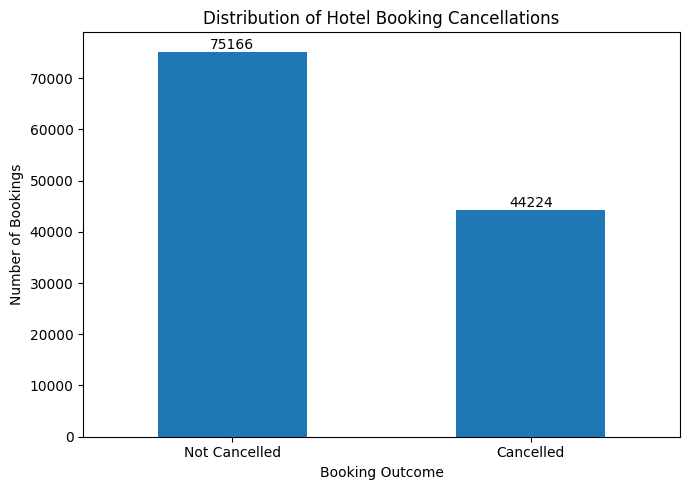

In [19]:
target_counts_named = df["is_canceled"].map({
    0: "Not Cancelled",
    1: "Cancelled"
}).value_counts()

ax = target_counts_named.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Distribution of Hotel Booking Cancellations")
plt.xlabel("Booking Outcome")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=0)

total = len(df)

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Target Distribution Observation

The dataset contains 75,166 non-cancelled bookings (approximately 62.96%) and 44,224 cancelled bookings (approximately 37.04%).

Therefore, the target variable is moderately imbalanced, with non-cancelled bookings forming the majority class. The imbalance is not extremely severe, but model evaluation should not rely only on accuracy. Metrics such as precision, recall, F1-score, ROC-AUC, and the confusion matrix will also be considered during model development.

## 3. Missing Value Analysis

Missing values are investigated to understand which variables contain incomplete information and how significant the missingness is.

No missing-value treatment is performed in this notebook. Appropriate handling strategies will be determined during the preprocessing stage.

Missing-value summary

In [20]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


Missing-value visualization

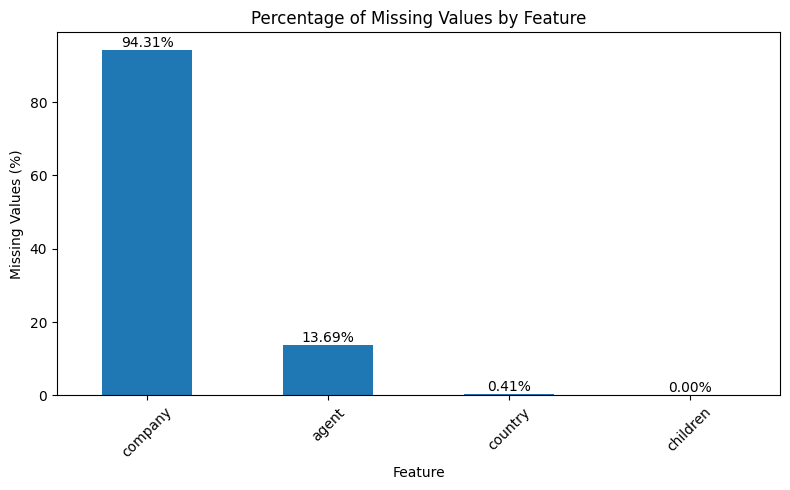

In [21]:
ax = missing_summary["Missing Percentage"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.tight_layout()
plt.show()

### Missing Value Observations

Missing values occur in four attributes:

- `company` has the largest proportion of missing values, at approximately 94.31%.
- `agent` contains approximately 13.69% missing values.
- `country` contains only a small proportion of missing values, approximately 0.41%.
- `children` contains only four missing records.

The meaning of these missing values must be investigated before selecting a treatment strategy. For example, a missing `company` or `agent` value may potentially represent a booking that was not associated with a company or travel agent rather than an accidental loss of information.

Therefore, rows or columns will not be removed solely because they contain missing values at this stage.